


## 🔬 Clusterização e PCA — A Prova Visual do Isolamento
Utilizamos o algoritmo **K-Means** para agrupar as residências por suas características estruturais e o **PCA (Análise de Componentes Principais)** para reduzir essa complexidade a duas dimensões. Se houver sobreposição total, o mercado é misto. Se houver barreiras claras, provaremos a existência de **"bolhas de elite"**.

In [1]:
import warnings
# Silencia todos os warnings (Deprecation, UserWarning, etc.)
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [11, 7]


caminhos_possiveis = ['train.csv', 'data/train.csv', '../data/train.csv']
train_df = None

for caminho in caminhos_possiveis:
    if os.path.exists(caminho):
        train_df = pd.read_csv(caminho)
        break

if train_df is None:
    raise FileNotFoundError("Não foi possível encontrar 'train.csv'. Certifique-se de que o arquivo está no diretório correto.")


#CLUSTERIZAÇÃO E PCA
features_cluster = [
    'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
    'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea'
]

features_presentes = [col for col in features_cluster if col in train_df.columns]
df_modelagem = train_df[features_presentes].copy().fillna(train_df[features_presentes].median())

#Normalização e aplicação do K-Means
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(df_modelagem)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
train_df['Cluster'] = kmeans.fit_predict(dados_normalizados)

### 📊 Mapeando os Perfis de Cada Cluster


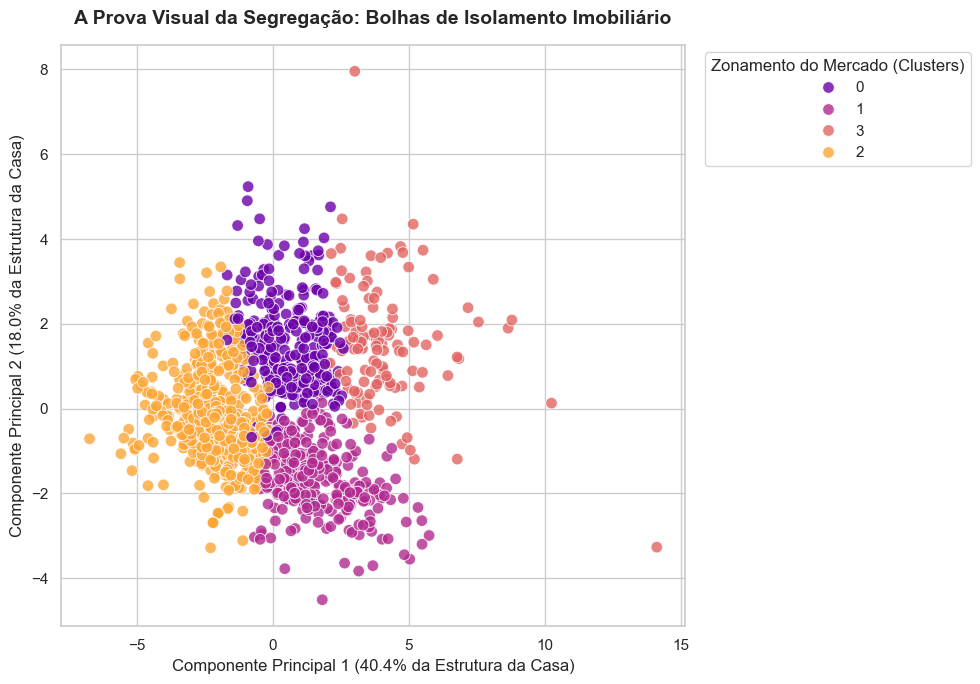


NARRATIVA DOS DADOS: O PERFIL MEDIO ISOLADO PELO MERCADO


Cluster,0,1,2,3
OverallQual,6.32,7.12,5.05,7.69
GrLivArea,1762.02,1592.19,1104.28,2596.99
GarageCars,1.84,2.28,1.26,2.60
SalePrice,179955.65,231381.74,126213.76,312933.07


In [2]:
pca = PCA(n_components=2, random_state=42)
componentes_pca = pca.fit_transform(dados_normalizados)
df_visualizacao = pd.DataFrame(data=componentes_pca, columns=['Componente PCA 1', 'Componente PCA 2'])
df_visualizacao['Cluster'] = train_df['Cluster'].astype(str)
variancia_explicada = pca.explained_variance_ratio_ * 100

#Gráfico de Dispersão do PCA
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente PCA 1', y='Componente PCA 2',
    hue='Cluster', palette='plasma', data=df_visualizacao,
    alpha=0.8, edgecolor='w', s=70
)
plt.title('A Prova Visual da Segregação: Bolhas de Isolamento Imobiliário', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'Componente Principal 1 ({variancia_explicada[0]:.1f}% da Estrutura da Casa)')
plt.ylabel(f'Componente Principal 2 ({variancia_explicada[1]:.1f}% da Estrutura da Casa)')
plt.legend(title='Zonamento do Mercado (Clusters)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#Resumo Narrativo da Segregação
perfil_clusters = train_df[features_presentes + ['SalePrice', 'Cluster']].groupby('Cluster').mean().round(2)
print("\n" + "="*80)
print("NARRATIVA DOS DADOS: O PERFIL MEDIO ISOLADO PELO MERCADO")
print("="*80)
display(perfil_clusters[['OverallQual', 'GrLivArea', 'GarageCars', 'SalePrice']].T)



##Algoritmo Apriori — Encontrando os "Combos da Exclusão"

A segregação não ocorre ao acaso. Ela é guiada por padrões de consumo rígidos. Se certos atributos básicos se tornam exclusivos de uma classe, eles se transformam em **artigos de luxo e barreiras de entrada**.

Usamos regras de associação para descobrir quais combinações de fatores determinam que uma casa pertença, com quase 100% de certeza, ao **Top 25% mais caro do mercado (Preço Elite)**.

In [3]:
print("\n" + "="*80)
print("ALGORITMO APRIORI: IDENTIFICANDO OS COMBOS DA EXCLUSÃO LUXUOSA")
print("="*80)


df_apriori = pd.DataFrame()


limiar_preco_alto = train_df['SalePrice'].quantile(0.75) # Top 25% mais caras (~ acima de $214k)

df_apriori['Excelente_Qualidade'] = train_df['OverallQual'] >= 8
df_apriori['Casa_Ampla_(>2k_sqft)'] = train_df['GrLivArea'] >= 2000
df_apriori['Garagem_Para_3+_Carros'] = train_df['GarageCars'] >= 3
df_apriori['Mais_de_2_Banheiros'] = train_df['FullBath'] >= 2
df_apriori['Construcao_Moderna_(>2000)'] = train_df['YearBuilt'] >= 2000
df_apriori['Preco_Elite_(Top_25%)'] = train_df['SalePrice'] >= limiar_preco_alto


frequent_itemsets = apriori(df_apriori, min_support=0.03, use_colnames=True)


regras = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.70)

#Filtrando apenas regras que resultam no preço de elite (Preco_Elite_(Top_25%)) no consequente
regras_exclusao = regras[regras['consequents'].apply(lambda x: 'Preco_Elite_(Top_25%)' in x)].copy()
regras_exclusao = regras_exclusao.sort_values(by='confidence', ascending=False)


if not regras_exclusao.empty:
    for idx, row in regras_exclusao.head(5).iterrows():
        antecedentes = ", ".join(list(row['antecedents']))
        confianca = row['confidence'] * 100
        lift = row['lift']
        print(f"GATILHO: Se a casa possui [{antecedentes}]")
        print(f"       -> A chance de pertencer à Elite de Preços é de {confianca:.1f}% (Lift: {lift:.2f}x mais provável)\n")
else:
    print("Nenhuma regra forte encontrada com o suporte mínimo atual. Tente reduzir o 'min_support'.")


ALGORITMO APRIORI: IDENTIFICANDO OS COMBOS DA EXCLUSÃO LUXUOSA
GATILHO: Se a casa possui [Excelente_Qualidade, Garagem_Para_3+_Carros, Casa_Ampla_(>2k_sqft)]
       -> A chance de pertencer à Elite de Preços é de 98.5% (Lift: 3.92x mais provável)

GATILHO: Se a casa possui [Garagem_Para_3+_Carros, Excelente_Qualidade, Mais_de_2_Banheiros, Casa_Ampla_(>2k_sqft)]
       -> A chance de pertencer à Elite de Preços é de 98.5% (Lift: 3.92x mais provável)

GATILHO: Se a casa possui [Garagem_Para_3+_Carros, Construcao_Moderna_(>2000), Casa_Ampla_(>2k_sqft)]
       -> A chance de pertencer à Elite de Preços é de 98.1% (Lift: 3.90x mais provável)

GATILHO: Se a casa possui [Garagem_Para_3+_Carros, Construcao_Moderna_(>2000), Mais_de_2_Banheiros, Casa_Ampla_(>2k_sqft)]
       -> A chance de pertencer à Elite de Preços é de 98.0% (Lift: 3.90x mais provável)

GATILHO: Se a casa possui [Garagem_Para_3+_Carros, Excelente_Qualidade, Construcao_Moderna_(>2000), Casa_Ampla_(>2k_sqft)]
       -> A chanc